In [1]:
from cuml.cluster import KMeans
import numpy as np
from sklearn.datasets import fetch_openml
#from keras.datasets import mnist
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import torch
import pandas as pd
import cudf
import pickle
import cv2

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

with open("kmeans_mnist_k10000.pkl", "rb") as f:
    model = pickle.load(f)

label_data = torch.tensor(model.labels_, dtype=torch.int64).to(device)
centroids = model.cluster_centers_


print(type(label_data), len(label_data))
print(type(centroids), centroids.shape)

cuda


<class 'torch.Tensor'> 40320000
<class 'cudf.core.dataframe.DataFrame'> (10000, 25)


torch.Size([10000, 576])


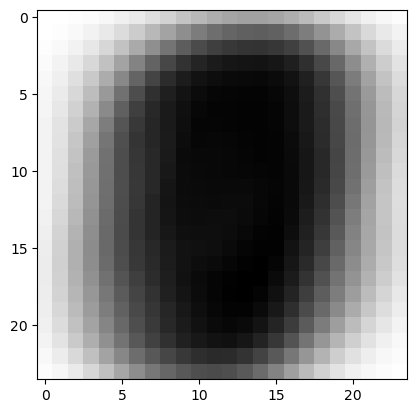

In [3]:
# calculate positional probability for each cluster
probability_matrix = torch.zeros(10000, 576)

batch_size = 100000

for start in range(0, len(label_data), batch_size):
    end = min(start + batch_size, len(label_data))
    batch_labels = label_data[start:end]
    pixel_indices = torch.arange(start, end, device=device) % 576
    
    temp_matrix = torch.zeros(10000, 576, device=device)
    temp_matrix.index_add_(0, batch_labels, torch.eye(576, device=device)[pixel_indices])
    
    probability_matrix += temp_matrix.cpu()

print(probability_matrix.shape)
plt.imshow(probability_matrix[8751].reshape(24,24), cmap='gray') # showing the epmty patch to ensure calculation is correct

In [4]:
mnist = fetch_openml('mnist_784', version=1)
X = mnist.data.astype(np.float32)
y = mnist.target.astype(int)

X_reshape = X.to_numpy().reshape(-1, 28, 28)

In [170]:
def init(origin_samples, sample_set, patch_size, image_dim):
    # Convert original to sample representation.
    sample = sample_set.to_pandas().values
    sample = sample / 255.
    sample = sample.reshape(10000, 5, 5)
    print('sample', sample.shape)

    # Generate window
    window = np.zeros(image_dim, dtype=np.float32)
    print('window', window.shape)

    # Generate window mask
    h, w = window.shape
    mask = np.zeros((h, w), dtype=np.float32)
    print('mask', mask.shape)

    # Initialize window with this seed
    seed_index = np.random.randint(10000)
    seed = sample[seed_index, 2:5, 2:5].reshape(3,3)
    print('seed_index', seed_index)
    print('seed', seed.shape)
    print(seed)

    # Place seed in center of window
    ph, pw = (h//2)-1, (w//2)-1
    window[ph:ph+3, pw:pw+3] = seed
    mask[ph:ph+3, pw:pw+3] = 1

    # Obtain padded versions of window and mask
    win = patch_size//2
    padded_window = cv2.copyMakeBorder(window, top=win, bottom=win, left=win, right=win, borderType=cv2.BORDER_CONSTANT, value=0.)
    padded_mask = cv2.copyMakeBorder(mask, top=win, bottom=win, left=win, right=win, borderType=cv2.BORDER_CONSTANT, value=0.)
    
    # Obtain views of the padded window and mask
    window = padded_window
    mask = padded_mask[win:-win, win:-win]

    # Create prob matrix
    probability_matrix = torch.zeros(10000, 576, device=device)
    batch_size = 100000
    for start in range(0, len(label_data), batch_size):
        end = min(start + batch_size, len(label_data))
        batch_labels = label_data[start:end]
        pixel_indices = torch.arange(start, end, device=device) % 576

        temp_matrix = torch.zeros(10000, 576, device=device)
        temp_matrix.index_add_(0, batch_labels, torch.eye(576, device=device)[pixel_indices])

        probability_matrix += temp_matrix
    prob_sum = probability_matrix.sum(dim=1).view(10000, 1)
    probability_matrix = probability_matrix / prob_sum
    probability_matrix = probability_matrix.reshape(10000, 24, 24)
    padded_probability_matrix = torch.nn.functional.pad(probability_matrix, (2,2,2,2), mode='constant', value=0)

    # Convert them all to tensors
    sample_tensor = torch.tensor(sample, dtype=torch.float32, device=device)
    padded_window_tensor = torch.tensor(padded_window, dtype=torch.float32, device=device)
    padded_mask_tensor = torch.tensor(padded_mask, dtype=torch.float32, device=device)
    window_tensor = torch.tensor(window, dtype=torch.float32, device=device)

    return sample_tensor, window_tensor, mask, padded_window_tensor, padded_mask_tensor, padded_probability_matrix

def ssdnorm(sample_set, window, mask, sub_prob_matrix, windowsize):

    def create_gaussian_kernel(size=windowsize, sigma=1.0):
        k = torch.arange(size, dtype=torch.float32) - (size - 1) / 2
        gauss = torch.exp(-0.5 * (k / sigma)**2)
        kernel = gauss[:, None] * gauss[None, :]
        return kernel / kernel.sum()

    gaussian_kernel = create_gaussian_kernel().to(device) * mask
    #print(gaussian_kernel)

    squared_diff = ((sample_set - window)**2) * gaussian_kernel# * sub_prob_matrix
    #print(squared_diff.shape)
    ssd = squared_diff.sum(dim=2).sum(dim=1)
    #print(ssd.shape)
    total_ssd = gaussian_kernel.sum(dim=1).sum(dim=0)
    #print(total_ssd)
    normalized_ssd = ssd / total_ssd

    return normalized_ssd


sample (10000, 5, 5)
window (28, 28)
mask (28, 28)
seed_index 3238
seed (3, 3)
[[0.83989745 0.6644656  0.42828205]
 [0.9375957  0.95434684 0.9168614 ]
 [0.17777237 0.18578431 0.28202507]]


Text(0.5, 1.0, 'prob_matrix')

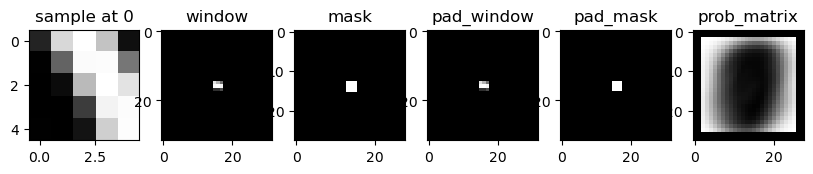

In [171]:
gen_dim = (28,28)

windowsize = 5
sample, window, mask, pad_window, pad_mask, probability_matrix = init(X_reshape, centroids, windowsize, gen_dim)

fig, axes = plt.subplots(1,6, figsize=(10,10))
axes[0].imshow(sample.cpu()[0], cmap='gray')
axes[1].imshow(window.cpu(), cmap='gray')
axes[2].imshow(mask, cmap='gray')
axes[3].imshow(pad_window.cpu(), cmap='gray')
axes[4].imshow(pad_mask.cpu(), cmap='gray')
axes[5].imshow(probability_matrix.cpu()[8751], cmap='gray')
axes[0].set_title('sample at 0')
axes[1].set_title('window')
axes[2].set_title('mask')
axes[3].set_title('pad_window')
axes[4].set_title('pad_mask')
axes[5].set_title('prob_matrix')

In [172]:
while np.sum(mask) < gen_dim[0] * gen_dim[1]:
# im = True
# while im == True:
    dilated_image = cv2.dilate(mask, np.ones((3,3)), iterations=1)
    new_mask = dilated_image - mask
    new_indices = np.where(new_mask == 1)
    # fig, axes = plt.subplots(new_indices[0].shape[0], 6, figsize=(10,12))
    # cnt = 0
    # plt.imshow(new_mask, cmap='gray')
    print('I count', new_indices[0].shape, 'new indices')
    for x, y in zip(new_indices[0], new_indices[1]):
        sub_pic = pad_window[x:x+windowsize, y:y+windowsize]
        sub_mask = pad_mask[x:x+windowsize, y:y+windowsize]
        sub_prob_matrix = probability_matrix[:,x:x+windowsize, y:y+windowsize]
        #print(sub_prob_matrix.shape)
        #axes[cnt][0].imshow(sub_pic)
        #axes[cnt][0].set_title(f'{x},{y}')
        ssds = ssdnorm(sample, sub_pic, sub_mask, sub_prob_matrix, windowsize)
        #print('cumulative ssds', ssds.shape)
        #print('ssds', ssds)
        #nonzero_ssds = ssds[ssds != 0]
        min_ssd = torch.min(ssds)
        #print('min ssd found:', min_ssd)
        min_threshold = min_ssd * (1.1)
        indices = torch.where(ssds <= min_threshold)
        print('indices size: ', indices[0].shape)
        N = indices[0].shape[0]
        select = np.random.choice(np.arange(N), size=1, p=np.ones(N) / float(N))
        #print('select: ', select, indices[0][select])
        sample_index = indices[0][select]
        # print(sample[sample_index])
        # print(window.shape)
        pad_window[x+2, y+2] = sample[sample_index].reshape(5,5)[3,3]
        window[x:x+windowsize,y:y+windowsize] += sample[sample_index].reshape(5,5)
        pad_mask[x+2,y+2] = 1
        mask[x,y] = 1

        # axes[cnt][0].imshow(pad_window.cpu(), cmap='gray')
        # axes[cnt][0].set_title(f'{x},{y}, padded {x + 2}, {y + 2}')
        # axes[cnt][0].scatter([y + 2], [x + 2], color='red', s=100, marker='o')
        # axes[cnt][0].axis('off')

        # axes[cnt][1].imshow(window.cpu(), cmap='gray')
        # axes[cnt][1].set_title(f'window')
        # axes[cnt][1].axis('off')

        # axes[cnt][2].imshow(sample[sample_index].cpu().reshape(5,5), cmap='gray')
        # axes[cnt][2].set_title(f'{sample_index.item()}')
        # axes[cnt][2].axis('off')
        
        # axes[cnt][3].imshow(sub_mask.cpu(), cmap='gray', vmin=0, vmax=1)
        # axes[cnt][3].set_title(f'sub_mask')
        # axes[cnt][3].axis('off')

        # axes[cnt][4].imshow(mask, cmap='gray', vmin=0, vmax=1)
        # axes[cnt][4].set_title(f'mask')
        # axes[cnt][4].axis('off')

        # axes[cnt][5].imshow(pad_mask.cpu(), cmap='gray', vmin=0, vmax=1)
        # axes[cnt][5].set_title(f'padded_mask')
        # axes[cnt][5].axis('off')
        # cnt +=1
    #im = False

I count (16,) new indices
indices size:  torch.Size([1])
indices size:  torch.Size([1])
indices size:  torch.Size([1])
indices size:  torch.Size([3])
indices size:  torch.Size([1])
indices size:  torch.Size([2])
indices size:  torch.Size([1])
indices size:  torch.Size([1])
indices size:  torch.Size([1])
indices size:  torch.Size([1])
indices size:  torch.Size([1])
indices size:  torch.Size([1])
indices size:  torch.Size([1])
indices size:  torch.Size([1])
indices size:  torch.Size([1])
indices size:  torch.Size([3])
I count (24,) new indices
indices size:  torch.Size([2])
indices size:  torch.Size([1])
indices size:  torch.Size([6])
indices size:  torch.Size([1])
indices size:  torch.Size([5])
indices size:  torch.Size([2])
indices size:  torch.Size([1])
indices size:  torch.Size([2])
indices size:  torch.Size([4])
indices size:  torch.Size([1])
indices size:  torch.Size([1])
indices size:  torch.Size([2])
indices size:  torch.Size([9])
indices size:  torch.Size([2])
indices size:  tor

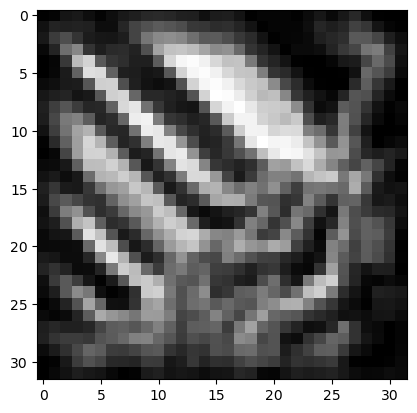

In [173]:
plt.imshow(window.cpu(), cmap='gray')

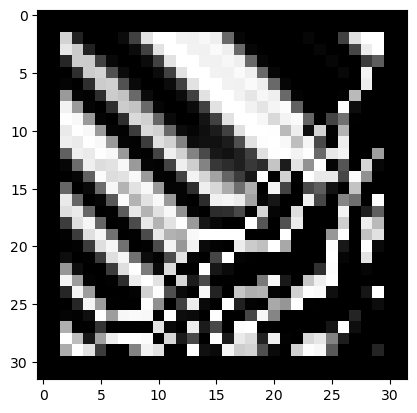

In [174]:
plt.imshow(pad_window.cpu(), cmap='gray')